# 09 - Clinical Co-variate Analysis

Do blood expression biomarkers add predictive value beyond donor demographics (SEX, AGE, RACE, DTHHRDY, TRISCHD)? Three RF models per pair: co-variates only, expression only, expression + co-variates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from trace_path.config import Config
from trace_path.data import (
    load_cache, variance_filter,
    build_confounder_matrix,
)
from trace_path.labels import discover_tissue_category_pairs
from trace_path.models import make_rf_model
from trace_path.utils import run_all_confounder_models_parallel
from trace_path.evaluation import plot_paired_auc_bar, plot_delta_bar

Config.ensure_dirs()

X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## 9.1 - Build Clinical Co-variate Matrix

RACE codes 98/99 (unknown) are treated as NaN and median-imputed.

In [2]:
X_conf = build_confounder_matrix(df_age, blood_subjid)
print(f"Clinical co-variate matrix: {X_conf.shape[0]} samples × {X_conf.shape[1]} features")
print(f"Features: {list(X_conf.columns)}")
print()
display(X_conf.describe().round(2))
display(X_conf.head(10))

Clinical co-variate matrix: 803 samples × 5 features
Features: ['SEX', 'AGE', 'RACE', 'DTHHRDY', 'TRISCHD']



,SEX,AGE,RACE,DTHHRDY,TRISCHD
count,803.00,803.00,796.00,788.00,803.00
mean,1.33,52.81,2.85,1.14,491.91
std,0.47,13.03,0.40,1.40,410.54
min,1.00,20.00,1.00,0.00,0.00
25%,1.00,47.00,3.00,0.00,79.00
50%,1.00,55.00,3.00,0.00,447.00
75%,2.00,63.00,3.00,2.00,824.50
max,2.00,70.00,4.00,4.00,1641.00


,SEX,AGE,RACE,DTHHRDY,TRISCHD
GTEX-1117F-0005-SM-HL9SH,2.0,66.0,2.0,4.0,1200.0
GTEX-111CU-0005-SM-GJ3PH,1.0,57.0,3.0,0.0,43.0
GTEX-111FC-0006-SM-H65Z1,1.0,61.0,3.0,1.0,1028.0
GTEX-111YS-0006-SM-5NQBE,1.0,62.0,3.0,0.0,74.0
GTEX-1122O-0005-SM-5O99J,2.0,64.0,3.0,0.0,35.0
GTEX-1128S-0005-SM-5P9HI,2.0,66.0,3.0,2.0,816.0
GTEX-113IC-0006-SM-5NQ9C,1.0,66.0,2.0,NaN,94.0
GTEX-113JC-0006-SM-5O997,2.0,53.0,3.0,2.0,611.0
GTEX-117XS-0005-SM-5PNU6,1.0,64.0,3.0,2.0,848.0
GTEX-117YW-0005-SM-5NQ8Z,1.0,58.0,3.0,3.0,785.0


## 9.2 - Discover Tissue x Category Pairs

In [3]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f"Total tissue × category pairs (≥ {Config.ALL_TISSUE_THRESHOLD} samples): {len(pairs_df)}")
display(pairs_df)

Total tissue × category pairs (≥ 50 samples): 59


,tissue,category,n_samples
0,Adipose - Subcutaneous,fibrosis,270
1,Adipose - Visceral (Omentum),fibrosis,139
2,Artery - Aorta,atherosis,229
3,Artery - Aorta,plaque,112
4,Artery - Aorta,atherosclerosis,101
5,Artery - Aorta,sclerotic,64
6,Artery - Aorta,calcification,54
7,Artery - Coronary,calcification,159
8,Artery - Coronary,atherosclerosis,153
9,Artery - Coronary,sclerotic,124


## 9.3 - Run Models (Parallelized by Tissue)

In [4]:
# Variance-filtered expression (top 20K genes) — same as notebook 07
X_wb_var, _ = variance_filter(X_wb)
print(f"Variance-filtered expression: {X_wb_var.shape[0]} samples × {X_wb_var.shape[1]} genes")

conf_results, conf_summary, comb_results, comb_summary = \
    run_all_confounder_models_parallel(
        pairs_df, df_meta_url, blood_subjid,
        X_wb_var, X_conf, make_rf_model
    )

print(f"Completed {len(conf_results)} clinical co-variate-only models")
print(f"Completed {len(comb_results)} expression+clinical co-variate models")

Variance-filtered expression: 803 samples × 20000 genes


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  2.8min


[Parallel(n_jobs=-1)]: Done   8 out of  20 | elapsed: 14.6min remaining: 21.9min


[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed: 17.4min remaining: 14.3min


[Parallel(n_jobs=-1)]: Done  14 out of  20 | elapsed: 17.9min remaining:  7.7min


[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed: 20.0min remaining:  3.5min


Completed 59 clinical co-variate-only models
Completed 59 expression+clinical co-variate models


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed: 25.3min finished


## 9.4 - Three-Way Comparison

Delta = AUC(Expression + co-variates) - AUC(Co-variates only) measures how much expression adds beyond demographics.

In [ ]:
conf_imp_rows = []
for tag, res in conf_results.items():
    tissue, category = res["tissue"], res["category"]
    from trace_path.labels import assign_donor_labels
    y_full, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, category, blood_subjid)
    keep = y_full.notna()
    X_c = X_conf.loc[keep]
    y_c = y_full.loc[keep].astype(int)
    # One-shot fit (not CV) — local median imputation for clinical co-variates.
    X_c = X_c.fillna(X_c.median())

    rf = make_rf_model()
    rf.fit(X_c, y_c)
    imp = dict(zip(X_c.columns, rf.feature_importances_))

    row = {"tissue": tissue, "category": category, "tag": tag,
           "mean_auc": res["mean_auc"]}
    row.update(imp)
    row["label"] = tag
    row["dominant_confounder"] = max(imp, key=imp.get)
    row["dominant_importance"] = max(imp.values())
    conf_imp_rows.append(row)

conf_imp_df = pd.DataFrame(conf_imp_rows)
conf_imp_df.to_csv(Config.TABLES_DIR / "confounder_feature_importances.csv", index=False)
print(f"Saved clinical co-variate feature importances → {len(conf_imp_df)} rows")
display(conf_imp_df.head())

In [ ]:
conf_summary.to_csv(Config.TABLES_DIR / "cv_results_confounder_only.csv", index=False)
comb_summary.to_csv(Config.TABLES_DIR / "cv_results_expr_plus_confounder.csv", index=False)

# Load expression-only RF results (baseline from notebook 07)
expr_only_path = Config.TABLES_DIR / "cv_results_all_tissue_rf.csv"
if not expr_only_path.exists():
    raise FileNotFoundError("Run notebook 07 first to generate expression-only RF results.")
expr_summary = pd.read_csv(expr_only_path)

three_way = (
    conf_summary[["tissue", "category", "mean_auc"]]
    .rename(columns={"mean_auc": "auc_conf"})
    .merge(
        expr_summary[["tissue", "category", "mean_auc"]]
        .rename(columns={"mean_auc": "auc_expr"}),
        on=["tissue", "category"], how="inner",
    )
    .merge(
        comb_summary[["tissue", "category", "mean_auc"]]
        .rename(columns={"mean_auc": "auc_comb"}),
        on=["tissue", "category"], how="inner",
    )
)

# Delta: how much does expression add beyond clinical co-variates alone?
three_way["delta"] = three_way["auc_comb"] - three_way["auc_conf"]
three_way = three_way.sort_values("auc_expr", ascending=False)
three_way.to_csv(Config.TABLES_DIR / "cv_three_way_comparison.csv", index=False)

print(f"Total models: {len(three_way)}")
print(f"Mean delta (Expression + co-variates − Co-variates only): {three_way['delta'].mean():.4f}")
print(f"Median delta: {three_way['delta'].median():.4f}")
display(three_way)

## 9.5 - Comparison: Expression + Co-variates vs Co-variates Only

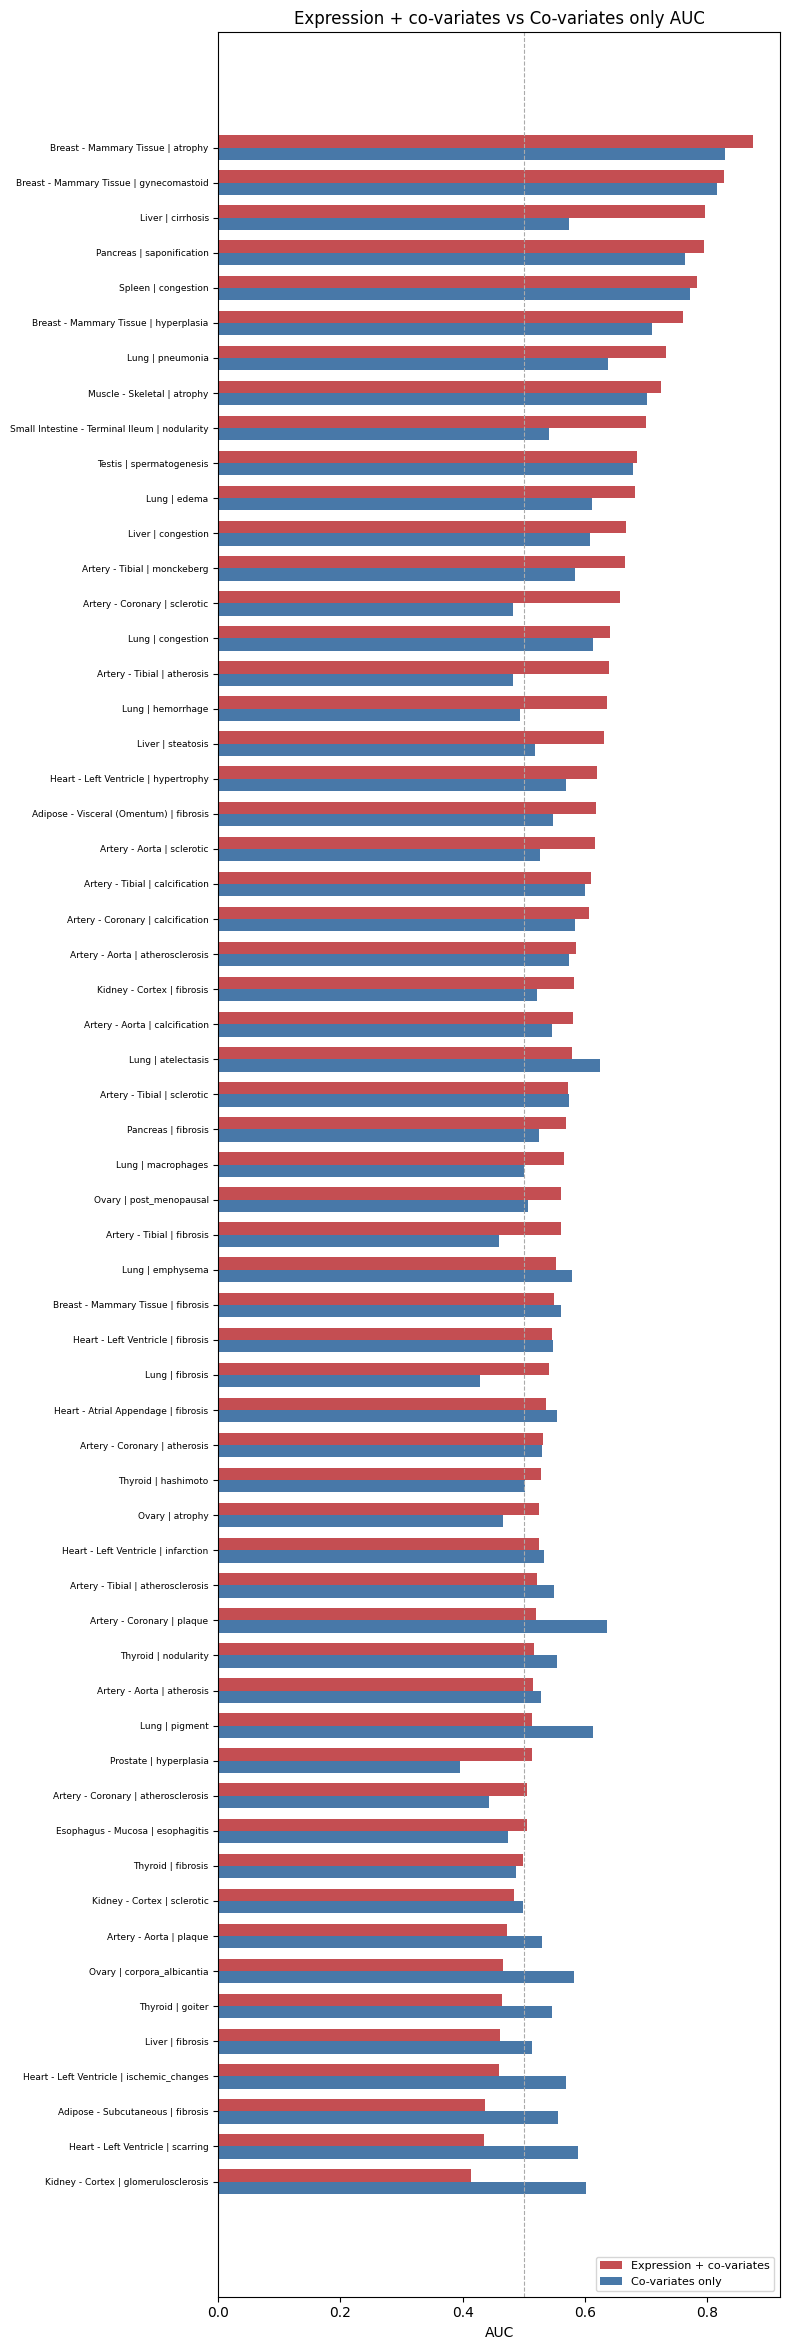

In [7]:
_ = plot_paired_auc_bar(
    three_way, auc_col_a='auc_comb', auc_col_b='auc_conf',
    label_a='Expression + co-variates', label_b='Co-variates only',
    title='Expression + co-variates vs Co-variates only AUC',
    save_path=Config.FIGURES_DIR / 'expr_conf_vs_conf_bar.pdf'
)

## 9.6 - Delta-AUC Bar Chart

Positive Delta means expression adds predictive value beyond demographics alone.

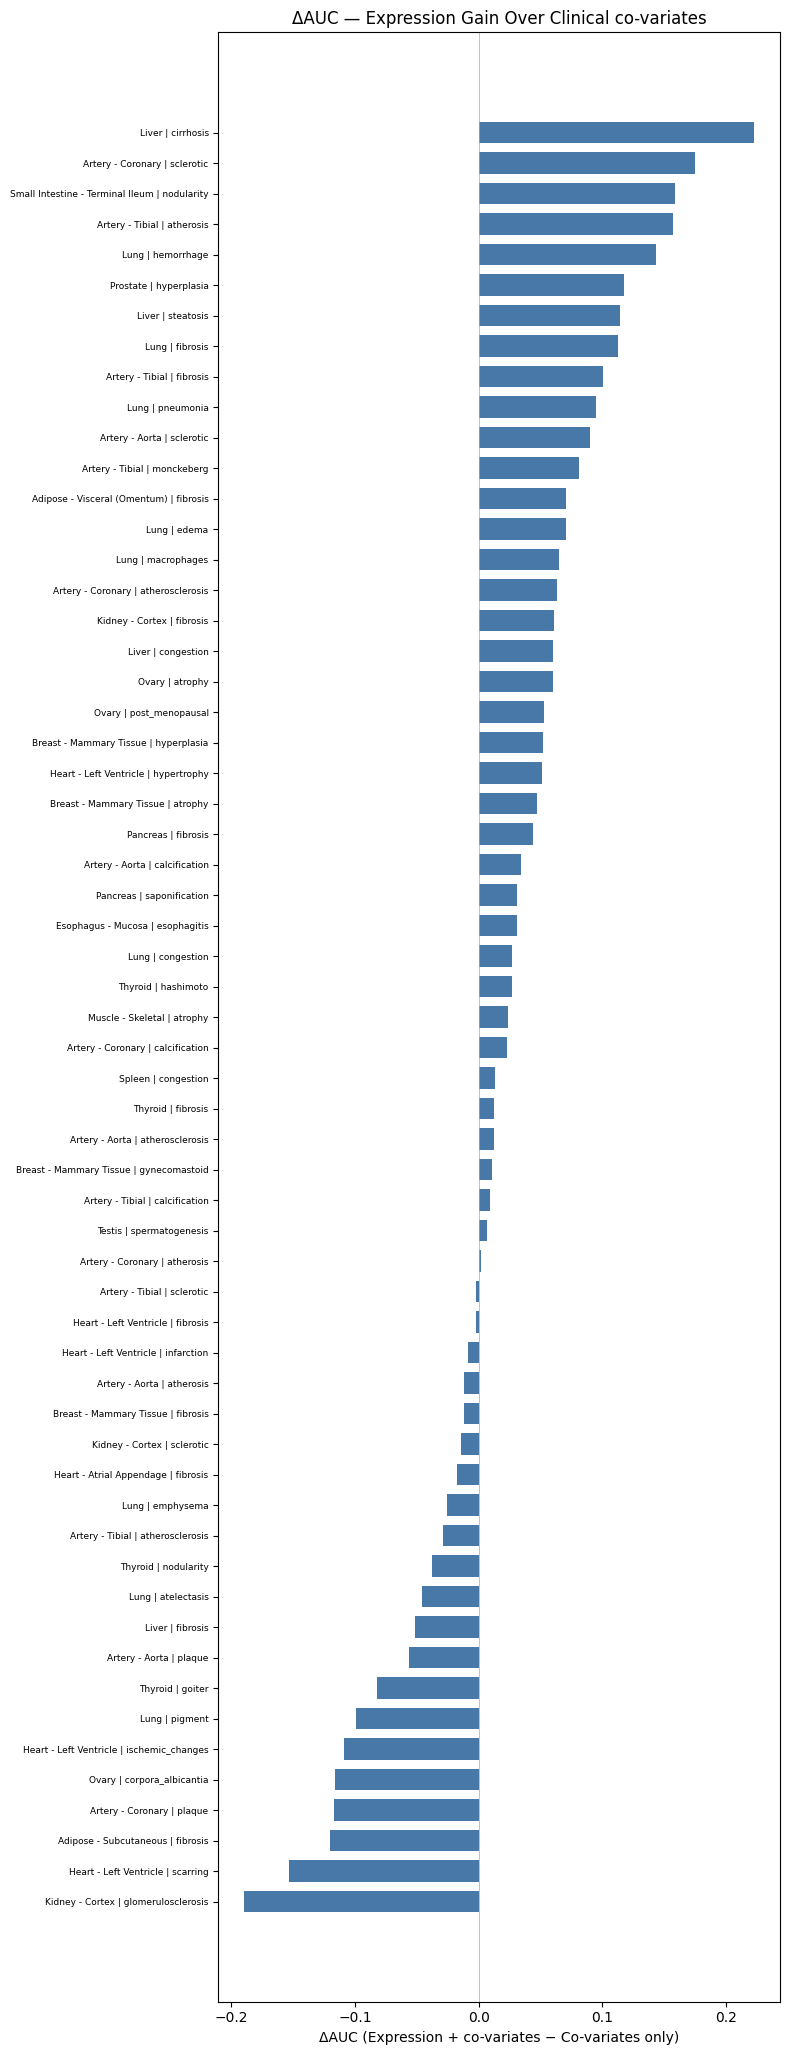

In [8]:
_ = plot_delta_bar(
    three_way, delta_col='delta',
    title='ΔAUC — Expression Gain Over Clinical co-variates',
    xlabel='ΔAUC (Expression + co-variates − Co-variates only)',
    save_path=Config.FIGURES_DIR / 'delta_auc_bar.pdf'
)

## 9.7 - Export Pathology Profiles

In [ ]:
profile = three_way[["tissue", "category", "auc_conf", "auc_expr", "auc_comb", "delta"]].merge(
    conf_imp_df[["tissue", "category", "SEX", "AGE", "RACE", "DTHHRDY", "TRISCHD"]],
    on=["tissue", "category"]
)
profile["label"] = profile["tissue"] + " | " + profile["category"]
profile = profile.sort_values("delta", ascending=False).reset_index(drop=True)
profile.to_csv(Config.TABLES_DIR / "pathology_profiles.csv", index=False)
print(f"Saved {len(profile)} rows → output/tables/pathology_profiles.csv")
display(profile)